# Railway Track Surface Defect Detection Training
## YOLOv8n on Railway Track Surface Defects Dataset (7 classes)

Run this notebook in Google Colab with **GPU runtime** (Runtime → Change runtime type → T4 GPU).
Training takes ~10 minutes for 50 epochs.

In [12]:
# 1. Install dependencies
!pip install -q ultralytics roboflow

In [13]:
# 2. Download dataset from Roboflow
# Replace this API key with your own if needed
from roboflow import Roboflow

API_KEY = "oAHPVi0KEDHQXipmAaqd"
rf = Roboflow(api_key=API_KEY)

# Railway Track Surface Defects dataset (v11, 2644 images, 7 classes)
project = rf.workspace('project-hkopa').project('railway-track-surface-defects-m5e4e')
version = project.version(11)

dataset_path = version.download('yolov8', location='railway_track_dataset')
print(f'Dataset downloaded to: {dataset_path}')

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: <roboflow.core.dataset.Dataset object at 0x7ce80f71e9c0>


In [14]:
# 3. Train YOLOv8n (detection)
import torch
from ultralytics import YOLO

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model = YOLO('yolov8n.pt')
results = model.train(
    data='/content/railway_track_dataset/data.yaml',
    epochs=70,
    imgsz=640,
    batch=16,
    device=device,
    project='railway_track_model',
    name='yolov8n',
    exist_ok=True,
    pretrained=True,
    optimizer='Adam',
    lr0=0.001,
    patience=20,
)
print('Training complete!')

Using device: cuda
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/railway_track_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, ove

In [15]:
# 4. Evaluate on validation set
metrics = model.val(data='/content/railway_track_dataset/data.yaml')
print(f'mAP50: {metrics.box.map50:.3f}')
print(f'mAP50-95: {metrics.box.map:.3f}')

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2696.6±829.3 MB/s, size: 99.5 KB)
val: Scanning /content/railway_track_dataset/valid/labels.cache... 325 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 325/325 113.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.2it/s 5.0s
                   all        325        987      0.521      0.532      0.495      0.289
                Cracks         88        206      0.473      0.282      0.294     0.0987
              Flakings         17         17      0.612      0.647      0.614      0.383
               Grooves         18         26      0.375      0.269      0.209      0.087
                 Joint          7          7      0.812          1      0.978      0.731
             Shellings          7 

In [16]:
import os
import shutil

best_path = '/content/runs/detect/railway_track_model/yolov8n/weights/best.pt'
if os.path.exists(best_path):
    shutil.copy(best_path, '/content/railway_track_best.pt')
    print(f'Model saved to: /content/railway_track_best.pt')
    print(f'Size: {os.path.getsize(best_path) / 1e6:.1f} MB')
else:
    print(f'Not found at {best_path}')
    import glob
    for f in glob.glob('/content/railway_track_model/**/*.pt', recursive=True):
        print(f'Found: {f}')

Model saved to: /content/railway_track_best.pt
Size: 6.3 MB


## Download the model

1. Click the folder icon on the left sidebar in Colab
2. Navigate to `/content/railway_track_best.pt`
3. Right-click → Download
4. Place the downloaded file in your project as `models/rail_surface_yolov8n.pt`
5. Then run the webapp with `python -m webapp.main`

In [17]:
# 6. Download directly from code
from google.colab import files
files.download('/content/railway_track_best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Test Inference on a Sample Image

Let's run inference on a sample image from the test set to visualize the model's predictions and understand its performance.

Streaming output truncated to the last 5000 lines.
1_MOV_20201221091849_8392_JPEG.rf.88948a371bd44e558d4732f358613ee0.jpg
1_MOV_20201221091849_8392_JPEG.rf.ed3af3e30fa5b37f2c97709f3c44e73e.jpg
1_MOV_20201221091849_8393_JPEG.rf.37c2925a28a46ba1e8577d240fe53f49.jpg
1_MOV_20201221091849_8393_JPEG.rf.3dd8fe5bf2986b262292c7885caba271.jpg
1_MOV_20201221091849_8393_JPEG.rf.5c16d16e0b29b8fd01498fdc0671d8fd.jpg
1_MOV_20201221091849_8394_JPEG.rf.10658f55d7e7149cfa58e9468b9263bf.jpg
1_MOV_20201221091849_8394_JPEG.rf.708096a1381e46871284cbe3e22490dc.jpg
1_MOV_20201221091849_8394_JPEG.rf.84147812ef386ca7da9b91ebc42f7470.jpg
1_MOV_20201221091849_8396_JPEG.rf.0be3d6250b39c5b1683a03c162c7b709.jpg
1_MOV_20201221091849_8396_JPEG.rf.9e4e947b4d0f251249802629f47fa840.jpg
1_MOV_20201221091849_8396_JPEG.rf.d4dd0c4b36a5dade87fe46e4a4f05d9a.jpg
1_MOV_20201221091849_8398_JPEG.rf.23bd98cf989a4941a208e9b826170b57.jpg
1_MOV_20201221091849_8398_JPEG.rf.8f6130c588ad8ffab3dbd840db5533fe.jpg
1_MOV_20201221091849_8398_

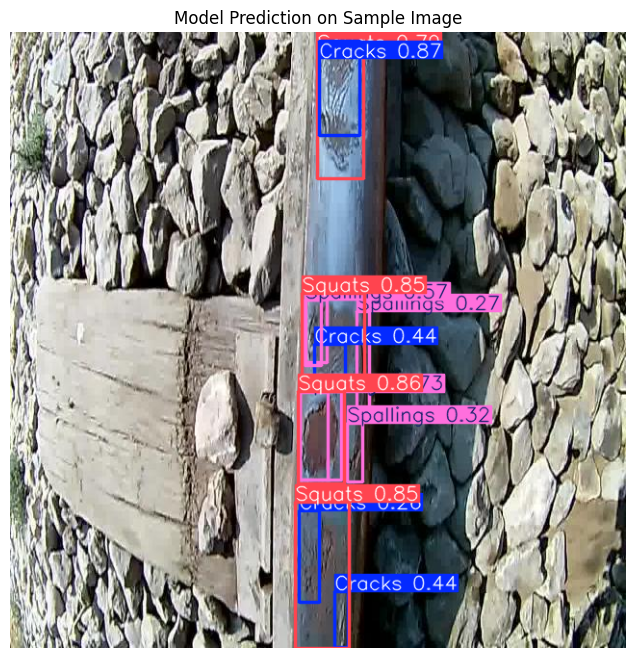

In [22]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import glob
import os

# Load the best trained model
model = YOLO('/content/railway_track_best.pt')

print('Listing contents of /content/railway_track_dataset/ :')
!ls -R /content/railway_track_dataset/

print('\nContents of data.yaml:')
!cat /content/railway_track_dataset/data.yaml

image_files = []

# Based on the ls output and data.yaml, the 'valid' split contains images for testing.
search_paths = [
    '/content/railway_track_dataset/valid/images/*.jpg',
    '/content/railway_track_dataset/valid/images/*.jpeg',
    '/content/railway_track_dataset/valid/images/*.png',
    '/content/railway_track_dataset/train/images/*.jpg', # Also check train if valid is empty
    '/content/railway_track_dataset/train/images/*.jpeg',
    '/content/railway_track_dataset/train/images/*.png'
]

for path_pattern in search_paths:
    found_files = glob.glob(path_pattern)
    if found_files:
        image_files.extend(found_files)
        break # Stop after finding files in the first matching pattern

if image_files:
    sample_image_path = image_files[0] # Use the first found image
    print(f'\nUsing sample image: {sample_image_path}')

    # Perform inference
    results = model.predict(source=sample_image_path, conf=0.25) # conf is confidence threshold

    # Display the results
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)  # convert to RGB
        plt.figure(figsize=(12, 8))
        plt.imshow(im_rgb)
        plt.axis('off')
        plt.title('Model Prediction on Sample Image')
        plt.show()
else:
    print('\nNo image files found in the valid or train directories. Please check the dataset path and contents.')